# Atividade 2

### Tópico 1: Gradiente Descendente
#### Letra A)

Primeiro vamos começar fazendo a automatização das operações matemáticas envolvidas para termos os dados necessários para plotar o gráfico

In [237]:
import matplotlib.pyplot as plt
import numpy as np 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

y_values = [1.4,1.9,3.2]
theta_1 = 0.64
theta_0 = 0.0
x_values = [0.5,2.3,2.9]
Learning_Rate = 0.01
gradients_list = []
step_history = []
squared_errors_list = []
theta_0_history = [0.0]
total_error_history = []
gradient_sum_history = []
max_steps = 50

def compute_gradients(y_values, theta_0, theta_1, x_values):
    gradients_list = []
    squared_errors_list = []
    theta_0_history = []
    for i in range(0,3):
        squa = (y_values[i] - (theta_0 + (theta_1 * x_values[i]))) ** 2
        derivada = -2 * (y_values[i] - (theta_0 + (theta_1 * x_values[i])))
        gradients_list.append(derivada)
        squared_errors_list.append(squa)
        theta_0_history.append(theta_0)

#    print(np.around(new_intercept, 2))
    return sum(squared_errors_list), sum(gradients_list), squared_errors_list, gradients_list
    
    
def gradient_step(y_values, theta_1, x_values, Learning_Rate,
                  theta_0, theta_0_history, step_history):
    _,_,squared_errors_list, gradients_list = compute_gradients(y_values, theta_0, theta_1, x_values)
    
    sum_squa = sum(squared_errors_list)
    
    deri_sum = sum(gradients_list)
    
    step_size = deri_sum * Learning_Rate
    step_history.append(step_size)


    theta_0 = theta_0 - step_size
    theta_0_history.append(theta_0)

    return theta_0, sum_squa, deri_sum, step_size,squared_errors_list,gradients_list


for i in range(max_steps):
    theta_0, sum_squa, deri_sum, step_size, squared_errors_list, gradients_list = gradient_step(y_values, theta_1, x_values, Learning_Rate, theta_0,theta_0_history, step_history)
    
    total_error_history.append(sum_squa)
    # Slope
    gradient_sum_history.append(deri_sum)
    
    print("Valores das derivadas:", np.around(gradients_list, 2))
    print("Soma dos quadrados residuais:", np.around(sum_squa, 2))
    print("Soma das derivadas:", np.around(deri_sum, 2))
    print("Step size:", np.around(step_size, 2))
    print("Intercepts até agora:", np.around(theta_0_history, 2))
    print("Novo intercept:", np.around(theta_0, 2))

    


Valores das derivadas: [-2.16 -0.86 -2.69]
Soma dos quadrados residuais: 3.16
Soma das derivadas: -5.7
Step size: -0.06
Intercepts até agora: [0.   0.06]
Novo intercept: 0.06
Valores das derivadas: [-2.05 -0.74 -2.57]
Soma dos quadrados residuais: 2.84
Soma das derivadas: -5.36
Step size: -0.05
Intercepts até agora: [0.   0.06 0.11]
Novo intercept: 0.11
Valores das derivadas: [-1.94 -0.63 -2.47]
Soma dos quadrados residuais: 2.56
Soma das derivadas: -5.04
Step size: -0.05
Intercepts até agora: [0.   0.06 0.11 0.16]
Novo intercept: 0.16
Valores das derivadas: [-1.84 -0.53 -2.37]
Soma dos quadrados residuais: 2.32
Soma das derivadas: -4.74
Step size: -0.05
Intercepts até agora: [0.   0.06 0.11 0.16 0.21]
Novo intercept: 0.21
Valores das derivadas: [-1.74 -0.44 -2.27]
Soma dos quadrados residuais: 2.1
Soma das derivadas: -4.45
Step size: -0.04
Intercepts até agora: [0.   0.06 0.11 0.16 0.21 0.25]
Novo intercept: 0.25
Valores das derivadas: [-1.65 -0.35 -2.18]
Soma dos quadrados residuais:

Por questões de didática, vamos explicar ponto a ponto desse código

In [238]:
#def compute_gradients(y_values, theta_0, theta_1, x_values):
#    gradients_list = []
#    squared_errors_list = []
#    theta_0_history = []
#    for i in range(0,3):
#        squa = (y_values[i] - (theta_0 + (theta_1 * x_values[i]))) ** 2
#        derivada = -2 * (y_values[i] - (theta_0 + (theta_1 * x_values[i])))
#        gradients_list.append(derivada)
#        squared_errors_list.append(squa)
#       theta_0_history.append(theta_0)
#
#    print('Valores das derivadas:')
#    print(np.around(gradients_list,2))
#    print(np.around(new_intercept, 2))
#    return squared_errors_list, gradients_list

Essa minha função eu utilizo para poder fazer as derivadas de cada termo da soma dos quadrados residuais utilizando a regra da cadeia e também serve para calcular a propria soma dos quadrados residuais para cada intercept

#### Basicamente:

$\frac{d}{d\,\,intercept} Sum\,\, of \,\,Squared \,\,Residuals = \frac{d}{d\,\,intercept} (1.4 - (intercept + 0.64 \cdot 0.5))^2 + \frac{d}{d\,\,intercept} (1.9 - (intercept + 0.64 \cdot 2.3))^2 + \frac{d}{d\,\,intercept} (3.2 - (intercept + 0.64 \cdot 2.9))^2 $


Acima temos um exemplo visto nos slides de um exemplo de utilização dessas derivadas

#### Onde após a regra da cadeia teremos:

$\frac{d}{d\,\,intercept} Sum\,\, of \,\,Squared \,\,Residuals = (-2 \cdot(1.4 - (intercept + 0.64 \cdot 0.5))) + (-2 \cdot(1.9 - (intercept + 0.64 \cdot 2.3))) + (-2 \cdot(3.2 - (intercept + 0.64 \cdot 2.9))) $

Sendo então visto na seguinte linha do código:

In [239]:
#  derivada = -2 * (y_values[i] - (theta_0 + (theta_1 * x_values[i])))

E a outra equação calculada por essa função é a soma dos quadrados residuais sendo sua formula igual a:

$ Sum\,\, of \,\,Squared \,\,Residuals =  (Altura - (intercept + Slope \cdot weight))^2 $

#### Sendo esta vista na função apresentada na seguinte linha:

In [240]:
# squa = (y_values[i] - (theta_0 + (theta_1 * x_values[i]))) ** 2

### Agora temos a função gradiente

In [241]:
#def gradient_step(y_values, theta_1, x_values, alpha,
#                  theta_0, theta_0_history, step_history):
#    squared_errors_list, gradients_list = compute_gradients(y_values, theta_0, theta_1, x_values)
#    
#    sum_squa = sum(squared_errors_list)
#    print('Valores da soma dos quadrados Residuais:')
#    print(np.around(sum_squa, 2))
#
#    deri_sum = sum(gradients_list)
#    print('Soma das derivadas:')
#    print(np.around(deri_sum, 2))
#
#    step_size = deri_sum * alpha
#    step_history.append(step_size)
#    print('Step size:')
#    print(np.around(step_size, 3))
#
#    theta_0 = theta_0 - step_size
#    theta_0_history.append(theta_0)
#
#    print(np.around(theta_0_history, 3))
#    print('Novo intercept:')
#    print(np.around(theta_0, 2))
#    
#    return theta_0, sum_squa, deri_sum, step_size

Acima temos a função do gradiente que é o calculo feito para serem achados cada intercept novo e para achar as somas das derivadas adquiridas anteriormente e para fazer a soma dos quadrados residuais

#### As duas somas ditas anteriormente se encontram nas seguintes linhas de código:

In [242]:
#    sum_squa = sum(squared_errors_list)
#    print('Valores da soma dos quadrados Residuais:')
#    print(np.around(sum_squa, 2))
#
#    deri_sum = sum(gradients_list)
#    print('Soma das derivadas:')
#    print(np.around(deri_sum, 2))

Em seguida nós temos os calculos do step_size que é dito pela seguinte formula:


$Step \,\,Size = Gradiente \,\,Descendente \cdot Learning \,\,Rate$

Representada nas seguintes linhas:


In [243]:
#    step_size = deri_sum * alpha
#    step_history.append(step_size)
#    print('Step size:')
#    print(np.around(step_size, 3))

E por fim temos que calcular o nosso novo intercept que será usado na próxima iteração, utilizando a seguinte formula:

$New \,\,Intercept = Old \,\,Intercept - Step\,\, Size$

Com essa formula sendo representada nas seguintes linhas de código:

In [244]:
#    theta_0 = theta_0 - step_size
#    theta_0_history.append(theta_0)

E agora falando apenas do for ao final do código ele serve para podermos ajustar conforme o necessário o número de iterações que queremos fazer

### Vamos agora plotar o Gráfico do Gradiente

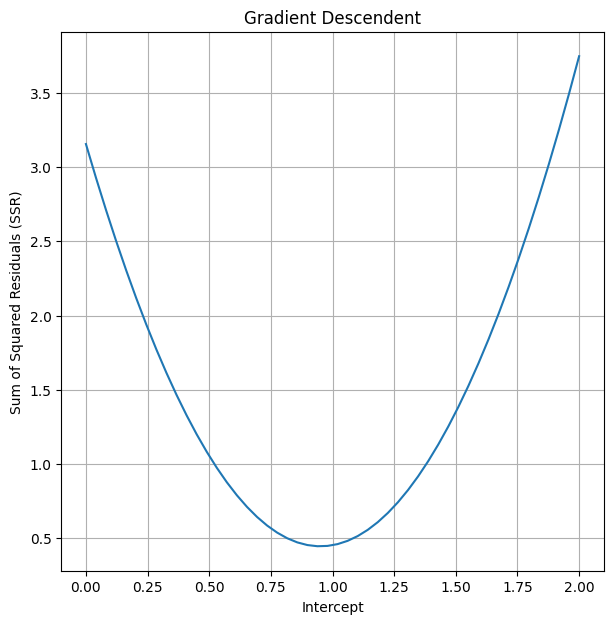

In [245]:
graph_x = np.linspace(0, 2)
graph_y = [compute_gradients(y_values, theta_0,theta_1, x_values)[0] for theta_0 in graph_x]

fig , ax = plt.subplots(figsize=(7,7))
ax.plot(graph_x, graph_y)
point_plot, = ax.plot([], [], 'o', color='orange')
tangent_line, = ax.plot([], [], '-')

ax.set_xlabel("Intercept")
ax.set_ylabel("Sum of Squared Residuals (SSR)")
ax.set_title("Gradient Descendent")
ax.grid(True)

In [246]:
def update(frame):
    theta_0 = theta_0_history[frame]
    errors = total_error_history[frame]
    slope = gradient_sum_history[frame]
    
    point_plot.set_data([theta_0], [errors])
    
    tan_x = np.linspace(min(graph_x), max(graph_x))
    tan_y = errors + slope * (tan_x - theta_0)
    tangent_line.set_data(tan_x,tan_y)
    
    return point_plot, tangent_line

anim = FuncAnimation(fig, update, frames=len(total_error_history), interval=100, blit=True)

HTML(anim.to_jshtml())